In [14]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [15]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [16]:
def scale(image, label):
    image = tf.cast(image, tf.float32)
    image /= 255.0
    return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [17]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [18]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [19]:
output_size = 10
hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [20]:
NUM_EPOCHS = 60
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(
    train_data,
    epochs=NUM_EPOCHS,
    callbacks=[early_stopping],
    validation_data=(validation_inputs, validation_targets),
    verbose=1
)

Epoch 1/60
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8840 - loss: 0.4168 - val_accuracy: 0.9390 - val_loss: 0.2227
Epoch 2/60
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9472 - loss: 0.1846 - val_accuracy: 0.9532 - val_loss: 0.1639
Epoch 3/60
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9597 - loss: 0.1382 - val_accuracy: 0.9582 - val_loss: 0.1457
Epoch 4/60
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9674 - loss: 0.1118 - val_accuracy: 0.9633 - val_loss: 0.1256
Epoch 5/60
540/540 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9730 - loss: 0.0934 - val_accuracy: 0.9658 - val_loss: 0.1209
Epoch 6/60
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9765 - loss: 0.0798 - val_accuracy: 0.9675 - val_loss: 0.1161
Epoch 7/60
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9793 - loss: 0.0709 - val_accuracy: 0.9682 - val_loss: 0.1089
Epoch 8/60
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9823 - loss: 0.0610 - val_accuracy:

In [21]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {:.2f}. Test accuracy: {:.2f}%'.format(test_loss, test_accuracy * 100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step - accuracy: 0.9702 - loss: 0.1004
Test loss: 0.10. Test accuracy: 97.02%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


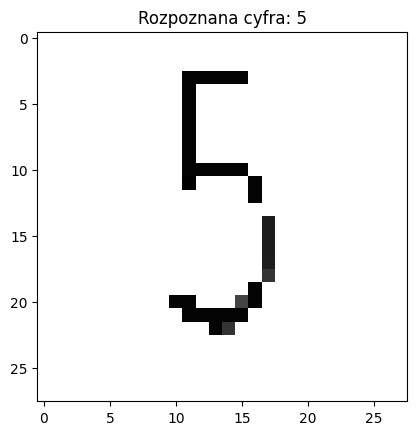

Pełny rozkład prawdopodobieństwa: [[3.8116929e-18 3.9870903e-30 1.9467922e-26 5.3780358e-03 0.0000000e+00
  9.9461800e-01 4.0726395e-06 2.3348181e-19 6.9289697e-17 4.5761008e-25]]
Model uważa, że na obrazku jest cyfra: 5


In [23]:
# 1. Wczytanie obrazka za pomocą OpenCV w skali szarości
img_array = cv2.imread('cyfra.png', cv2.IMREAD_GRAYSCALE)

# 2. Zmiana rozmiaru do 28x28 pikseli (wymóg sieci MNIST)
img_resized = cv2.resize(img_array, (28, 28))

# 3. Normalizacja wartości pikseli do przedziału 0-1
img_normalized = img_resized / 255.0

# 4. Dostosowanie wymiarów (z 28x28 do 1x28x28x1 - sieć oczekuje partii obrazów)
img_input = np.expand_dims(img_normalized, axis=(0, -1))

# 5. Predykcja modelu
prediction = model.predict(img_input)
predicted_digit = np.argmax(prediction)

# 6. Wyświetlenie wyniku i obrazka
plt.imshow(img_resized, cmap='gray')
plt.title(f"Rozpoznana cyfra: {predicted_digit}")
plt.show()

print(f"Pełny rozkład prawdopodobieństwa: {prediction}")
print(f"Model uważa, że na obrazku jest cyfra: {predicted_digit}")